In [3]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit,  ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.transpiler.passes import ALAPScheduleAnalysis
from qiskit.transpiler import PassManager
import csv


In [8]:
## Save your IBM Quantum account and set it as your default account.
your_api_key = "9hJ2tQCPO5ZQfbTqHZJ9MVvWw_VIcdVf-PSrSRU2A9Sx"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/5e68d80097b441d1a02d32bf585bedac:6ef82fed-0a87-4949-a472-bfa604ffc372::"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="Surface_Code",
    overwrite=True
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")
backend = service.backend("ibm_sherbrooke")
backend.name

'ibm_sherbrooke'

In [5]:
backend_properties = backend.properties()


In [19]:
# scot qreg 
def split_surface(backend):
    qreg = QuantumRegister(28, 'q')
    creg = ClassicalRegister(28, 'c')

    qc = QuantumCircuit(qreg, creg)


    qc.cx(1, 0)
    qc.cx(27, 0)

    qc.cx(1, 2)
    qc.cx(3, 2)

    qc.cx(3, 4)
    qc.cx(5, 4)

    qc.cx(5, 6)
    qc.cx(7, 6)

    qc.cx(7, 8)
    qc.cx(9, 8)

    qc.cx(9, 10)
    qc.cx(11, 10)

    qc.cx(11, 12)
    qc.cx(13, 12)

    qc.cx(13, 14)
    qc.cx(15, 14)

    qc.cx(15, 16)
    qc.cx(17, 16)

    qc.cx(17, 18)
    qc.cx(19, 18)

    qc.cx(19, 20)
    qc.cx(21, 20)

    qc.cx(21, 22)
    qc.cx(23, 22)

    qc.cx(23, 24)
    qc.cx(25, 24)

    qc.cx(25, 26)
    qc.cx(27, 26)


    qc.barrier()
    for i in range(28):
        qc.measure(i, i)
    
    display (qc.draw('mpl'))

    layout = list(range(13))  # [0, 1, ..., 12]
    layout.append(17)         # add 17
    layout.extend(range(30, 17, -1))  # add [30, 29, ..., 18]
    layout.append(14)         # add 14
    print(layout)


    pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend,initial_layout= layout )
    transpiled_qc1 = pass_manager.run(qc)
    # display( transpiled_qc1.draw("mpl") )
    
    return transpiled_qc1

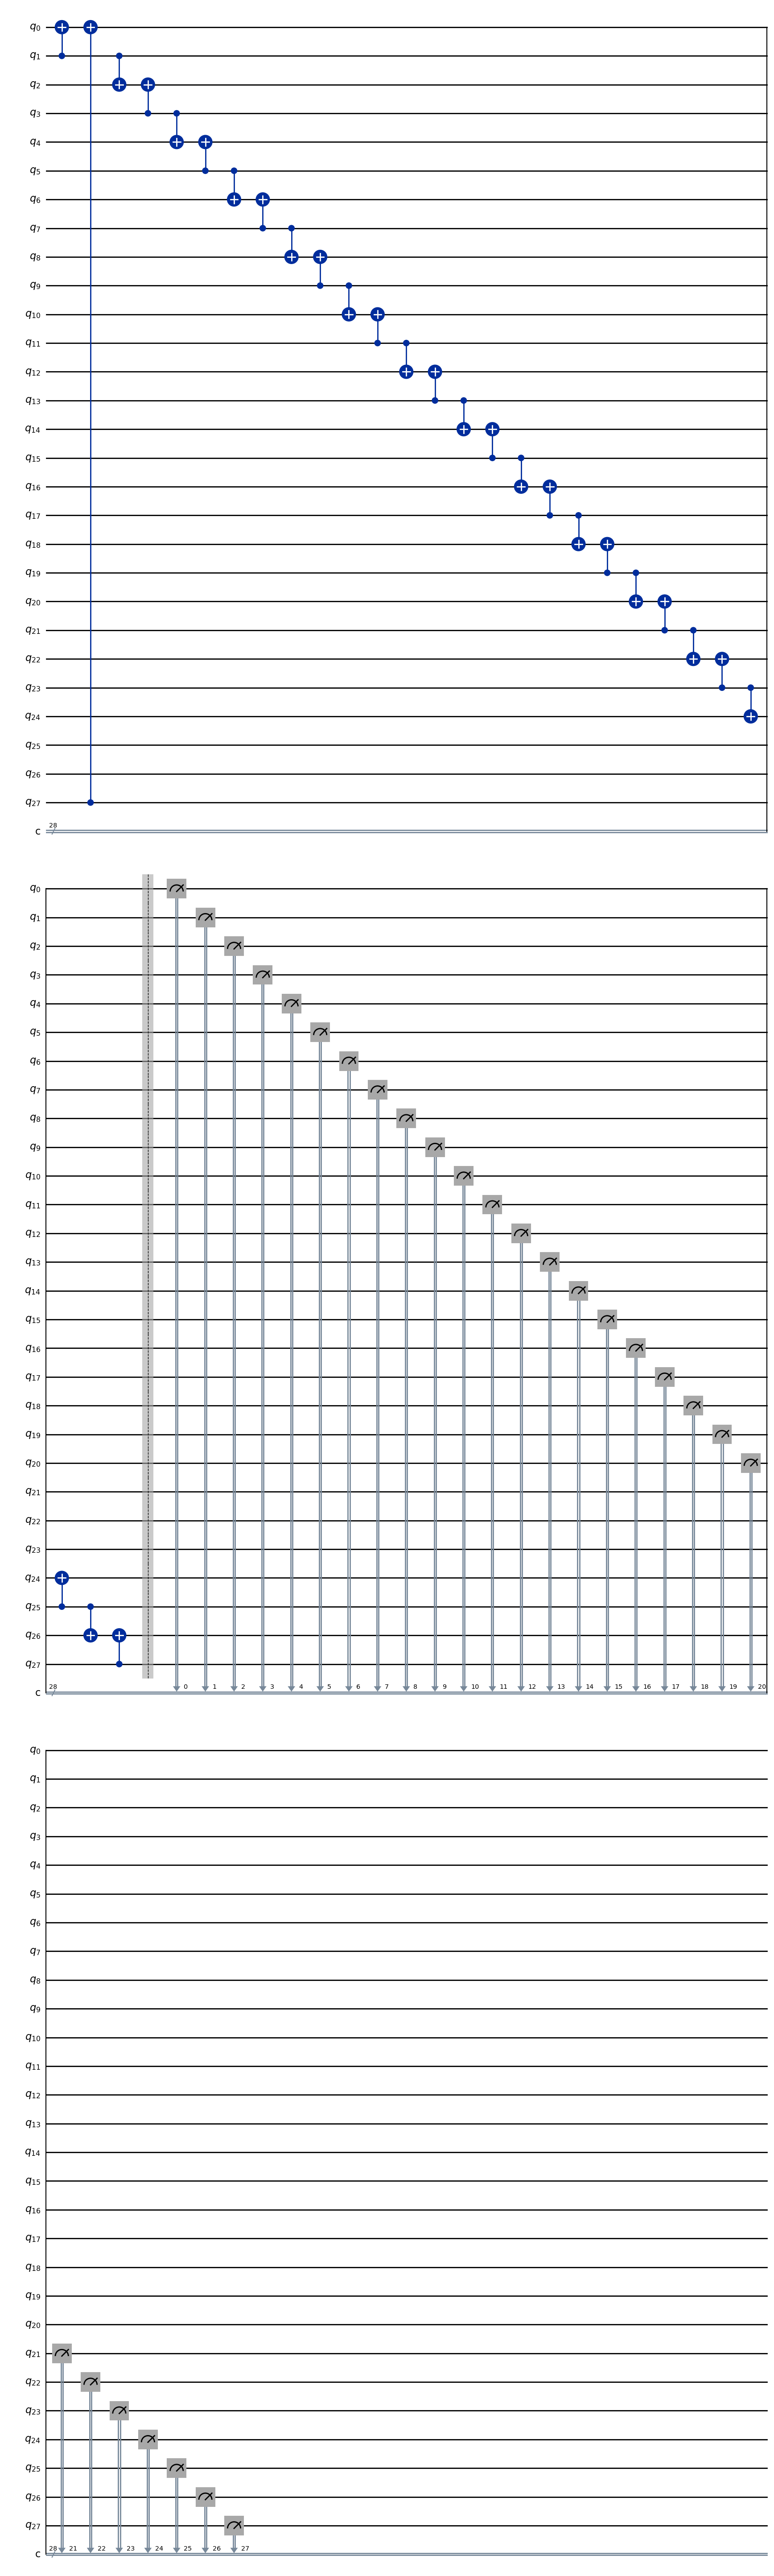

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 17, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 14]


In [20]:
transpiledQc = split_surface(backend)

In [21]:
sampler = Sampler(mode=backend)

for i in range(3):
    job = sampler.run([transpiledQc], shots=10000)
    print("Job ID:", job.job_id())

Job ID: d21093lofqqs73dc62a0
Job ID: d210944lir9s73aidda0
Job ID: d21094clir9s73aiddag


In [11]:
def get_and_save_job_results(job_id, filename="split_surface_from_0.csv"):
    """
    Retrieves results from an IBM Quantum job and saves them to a CSV file.

    Args:
        job_id (str): The ID of the IBM Quantum job.
        filename (str): The name of the CSV file to save the results to.
    """
    try:
        retrieved_job = service.job(job_id)
        retrieved_job.result()
        result = retrieved_job.result()[0] # get the first result.
        counts = result.join_data().get_counts()

        with open(filename, "a", newline="") as csvfile:
            writer = csv.writer(csvfile)

            # Check if the file is empty and write the header if it is.
            if csvfile.tell() == 0:
                writer.writerow(["Job ID", "State", "Count"])

            writer.writerow([job_id]) #write the job id
            for state, count in counts.items():
                writer.writerow([state, count])

        print(f"Results for job ID '{job_id}' saved to '{filename}'")

    except Exception as e:
        print(f"An error occurred: {e}")

In [12]:
get_and_save_job_results("d21093lofqqs73dc62a0", "split_surface_from_0.csv")

Results for job ID 'd21093lofqqs73dc62a0' saved to 'split_surface_from_0.csv'
